# SHAP AND LIME

1. Regression Gold-Silver Shap-Lime (create a visual)
2. Clustering using Kmeans with PCA and UMAP

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [5]:
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

In [47]:
gold = yf.download("GC=F", period="1y",interval="1d")      # Gold Futures
silver = yf.download("SI=F", period="1y",interval="1d")    # Silver Futures

gold = gold[['Close']]
silver = silver[['Close']]

data = pd.concat([gold, silver], axis=1)
data.columns = ['Gold_Close', 'Silver_Close']

data.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [48]:
data

,Gold_Close,Silver_Close
Date,,
2025-03-04,2909.600098,32.108002
2025-03-05,2915.300049,32.858002
2025-03-06,2916.600098,33.063000
2025-03-07,2904.699951,32.548000
2025-03-10,2891.000000,32.275002
...,...,...
2026-02-26,5176.500000,86.998001
2026-02-27,5230.500000,92.681999
2026-03-02,5294.399902,88.283997


In [49]:
data['Gold_prev'] = data['Gold_Close'].shift(1)
data['Silver_prev'] = data['Silver_Close'].shift(1)

data['Gold_ma5'] = data['Gold_Close'].rolling(5).mean()
data['Silver_ma5'] = data['Silver_Close'].rolling(5).mean()
data['Gold_ma9'] = data['Gold_Close'].rolling(9).mean()
data['Silver_ma9'] = data['Silver_Close'].rolling(9).mean()
data['Gold_ma21'] = data['Gold_Close'].rolling(21).mean()
data['Silver_ma21'] = data['Silver_Close'].rolling(21).mean()

data.dropna(inplace=True)

In [50]:
data.columns

Index(['Gold_Close', 'Silver_Close', 'Gold_prev', 'Silver_prev', 'Gold_ma5',
       'Silver_ma5', 'Gold_ma9', 'Silver_ma9', 'Gold_ma21', 'Silver_ma21'],
      dtype='object')

In [51]:
data

,Gold_Close,Silver_Close,Gold_prev,Silver_prev,Gold_ma5,Silver_ma5,Gold_ma9,Silver_ma9,Gold_ma21,Silver_ma21
Date,,,,,,,,,,
2025-04-01,3118.899902,34.158001,3122.800049,34.457001,3081.859961,34.437801,3056.033312,34.059111,2997.300002,33.648667
2025-04-02,3139.899902,34.499001,3118.899902,34.158001,3105.659961,34.531001,3067.133301,34.138334,3008.266660,33.762524
2025-04-03,3097.000000,31.844000,3139.899902,34.499001,3113.019971,33.920401,3075.888862,33.977667,3016.919038,33.714238
2025-04-04,3012.000000,29.115999,3097.000000,31.844000,3098.119971,32.814800,3075.766629,33.516667,3021.461891,33.526286
2025-04-07,2951.300049,29.510000,3012.000000,29.115999,3063.819971,31.825400,3067.722195,33.017556,3023.680943,33.381619
...,...,...,...,...,...,...,...,...,...,...
2026-02-26,5176.500000,86.998001,5206.399902,90.939003,5160.539941,86.840001,5074.444390,82.285778,5014.909505,84.040096
2026-02-27,5230.500000,92.681999,5176.500000,86.998001,5194.779980,88.919801,5097.611057,83.933668,5011.523786,83.067286
2026-03-02,5294.399902,88.283997,5230.500000,92.681999,5212.719922,89.272000,5143.333279,85.582223,5010.380929,81.840953


In [17]:
# Predict GOLD price
X = data[['Silver_Close', 'Gold_prev', 'Silver_prev', 'Gold_ma5', 'Silver_ma5']]
y = data['Gold_Close']


In [52]:
X = data.drop(['Gold_Close'],axis=1)

In [53]:
y = data['Gold_Close']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

rf_reg.fit(X_train, y_train)

preds = rf_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))

print("RMSE:", rmse)

RMSE: 62.79834514403055


In [26]:
from sklearn.linear_model import LinearRegression

In [56]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

preds = lin_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))

print("RMSE:", rmse)

RMSE: 41.56861229876854



Generating SHAP summary plot for Random Forest...


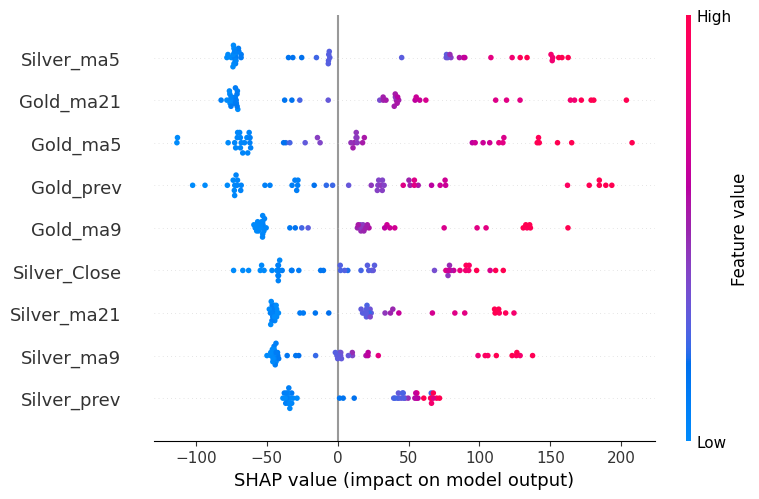

In [57]:
explainer = shap.TreeExplainer(rf_reg)
shap_values = explainer.shap_values(X_test)

print("\nGenerating SHAP summary plot for Random Forest...")
shap.summary_plot(shap_values, X_test)


Generating SHAP summary plot for Linear Regression...


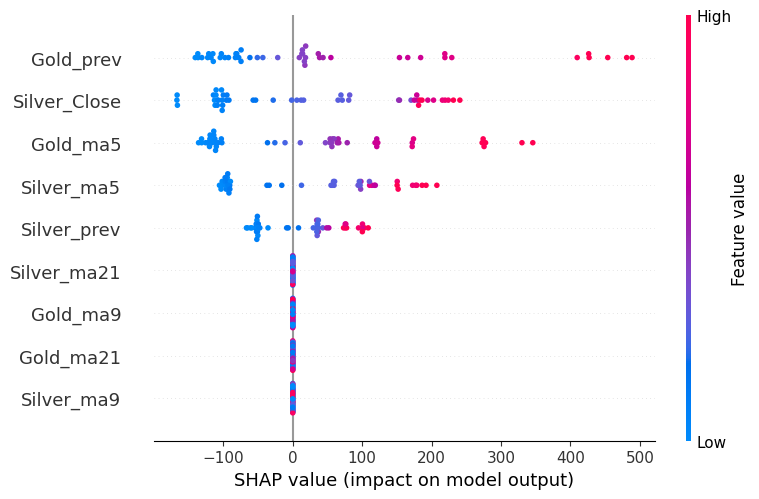

In [58]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

print("\nGenerating SHAP summary plot for Linear Regression...")
shap.summary_plot(shap_values, X_test)

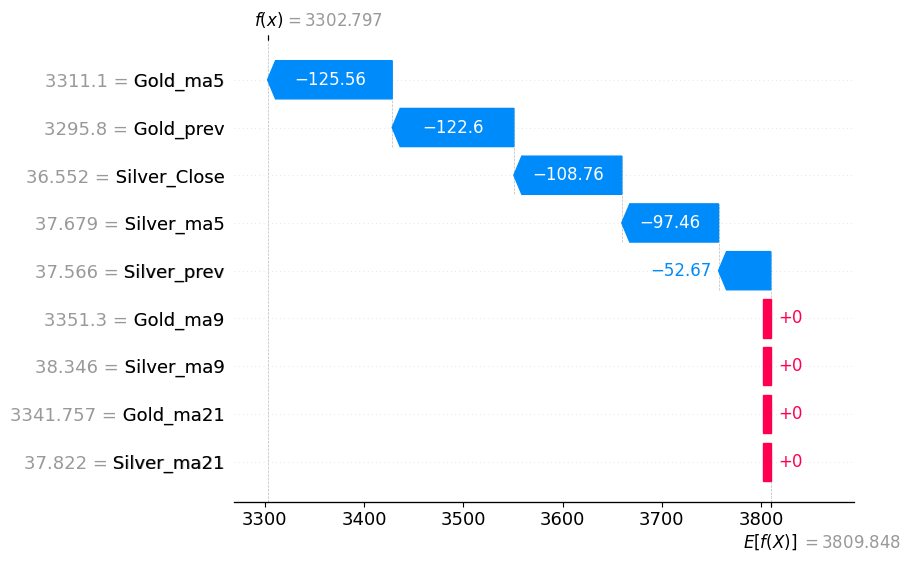

In [59]:
shap.plots.waterfall(shap_values[0])

C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). T


LIME Explanation for one prediction:
MODEL: RANDOM FOREST


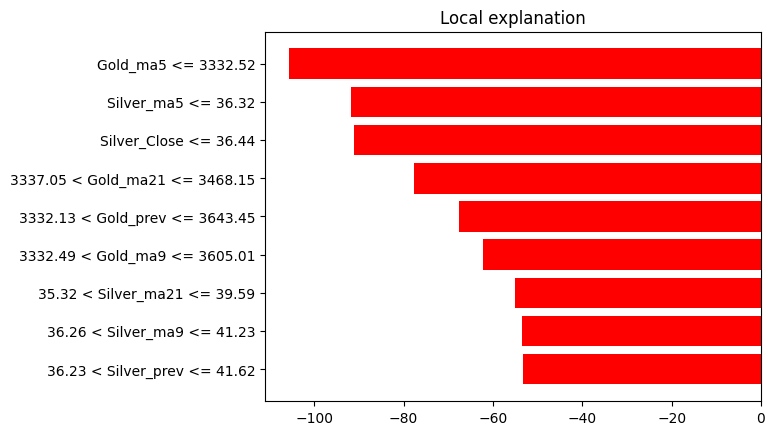

In [60]:
# 6. LIME Explainability
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    mode='regression'
)

i = 5  # choose a test sample

exp = explainer_lime.explain_instance(
    X_test.iloc[i],
    rf_reg.predict
)

print("\nLIME Explanation for one prediction:")
print("MODEL: RANDOM FOREST")
# exp.show_in_notebook(show_table=True)
# If running in script instead of notebook
fig = exp.as_pyplot_figure()
plt.show()

C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). T


LIME Explanation for one prediction:
MODEL: Linear Regression


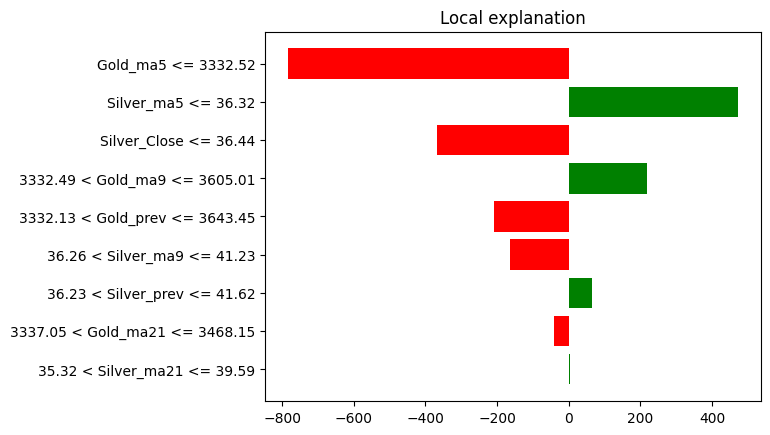

In [61]:
# 6. LIME Explainability
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    mode='regression'
)

i = 5  # choose a test sample

exp = explainer_lime.explain_instance(
    X_test.iloc[i],
    lin_reg.predict
)

print("\nLIME Explanation for one prediction:")
print("MODEL: Linear Regression")
# If running in script instead of notebook
fig = exp.as_pyplot_figure()
plt.show()